In [1]:
import os
import re
import glob
import pandas as pd
from IPython.display import display, Markdown
from collections import OrderedDict
import pylhe
from scipy.interpolate import griddata
from scipy.interpolate import interp1d
import pyslha
import xml.etree.ElementTree as ET
import pyslha
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# sns.set(style="white", context="paper", font_scale=1.8, 
#         rc={"text.usetex": True, 
#             'font.family':'Times New Roman', 
#             'font.serif':'Times New Roman', 
#             "savefig.dpi": 300})
# #plt.rcParams['text.usetex'] = True
# # Configure the plot aesthetics and labels
# def configure_axes(ax, info=None):  
#     if info is not None:
#         multiline_info = "\n".join(info)
#         ax.text(0.2, 0.5, multiline_info, transform=ax.transAxes, fontsize=16,
#                 color='black', bbox=dict(facecolor='silver', alpha=0.5,
#                                          edgecolor='silver', boxstyle='round,pad=0.8',
#                                          linewidth=0.2))
#     def set_x_label(label, size=18, labelpad=5):
#         ax.set_xlabel(label, size=size, labelpad=labelpad, loc="right", fontname='serif')
#     def set_y_label(label, size=18, labelpad=5):
#         ax.set_ylabel(label, size=size, labelpad=labelpad, loc="top", fontname='serif')
#     def set_legend(framealpha=0.5, fontsize='16'):
#         ax.legend(framealpha=framealpha, loc='best', fontsize=fontsize)
#     ax.set_x_label = set_x_label
#     ax.set_y_label = set_y_label
#     ax.minorticks_on()
#     ax.tick_params(direction='in', length=10, width=1.1, colors='black', which='major', top=True, right=True)
#     ax.tick_params(direction='in', length=5, width=0.6, colors='black', which='minor', top=True, right=True)
#     ax.xaxis.set_ticks_position('both')
#     ax.yaxis.set_ticks_position('both')
#     for spine in ['left', 'right', 'top', 'bottom']:
#         ax.spines[spine].set_linewidth(1.2)
#     sns.despine(left=False, bottom=False, right=False, top=False, offset=None, trim=False)
#     ax.tick_params(axis='x', labelcolor='black', labelsize=16)
#     ax.tick_params(axis='y', labelcolor='black', labelsize=16)

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution
pd.set_option('display.max_rows', 200)

cm = plt.colormaps['RdYlBu']


In [2]:
pd.read_pickle('../ma5_test_spin1/ma5Results_axial.pcl')

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Efficiency,Stat,Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV)
0,IM0,5.606250,5.608196,0.137388,0.000091,5.117341,dma_1_1000,1000.0,1.0
1,IM1,3.036544,3.039287,0.100463,0.000080,5.117341,dma_1_1000,1000.0,1.0
2,IM2,2.358826,2.363618,0.071285,0.000068,5.117341,dma_1_1000,1000.0,1.0
3,IM3,1.835576,1.843787,0.049401,0.000057,5.117341,dma_1_1000,1000.0,1.0
4,IM4,1.611891,1.624458,0.034913,0.000049,5.117341,dma_1_1000,1000.0,1.0
5,IM5,1.299057,1.314573,0.018010,0.000035,5.117341,dma_1_1000,1000.0,1.0
6,IM6,1.291878,1.313118,0.008753,0.000025,5.117341,dma_1_1000,1000.0,1.0
7,IM7,1.161691,1.179182,0.003773,0.000016,5.117341,dma_1_1000,1000.0,1.0
8,IM8,1.052121,1.062498,0.002063,0.000012,5.117341,dma_1_1000,1000.0,1.0
9,IM9,1.373944,1.358772,0.000855,0.000008,5.117341,dma_1_1000,1000.0,1.0


In [3]:
# SAF and CLs file patterns
saf_patterns = [
    '../ma5_test_spin1/Output/SAF/*/*.saf'
]
cls_patterns = [
    '../ma5_test_spin1/Output/SAF/*/CLs_output.dat'
]

saf_files = sorted([file for pattern in saf_patterns for file in glob.glob(pattern)])
cls_files = sorted([file for pattern in cls_patterns for file in glob.glob(pattern)])
inputListPattern = sorted(glob.glob('../ma5_test_spin1/Input/*.list'))

if len(inputListPattern) != len(cls_files):
    print(f"Warning: Mismatch in input files ({len(inputListPattern)}) and CLs files ({len(cls_files)})!")

sample_global_info_pattern = re.compile(r"<SampleGlobalInfo>(.*?)</SampleGlobalInfo>", re.DOTALL)

saf_to_theoretical = {}
final_results = []
allDataDicts = []


# Process SAF and CLs files in pairs
for inputFile, cls_file, saf_file in zip(inputListPattern, cls_files, saf_files):
    try:
        # Read the HepMC file location from the input file
        with open(inputFile, 'r') as f:
            hepMCfile = f.read().strip()
        
        hepDir = os.path.dirname(hepMCfile)
        banner_candidates = glob.glob(f"{hepDir}/**/*banner.txt", recursive=True)
        
        if not banner_candidates:
            print(f"No banner file found for input file: {inputFile}")
            continue
        
        # Use the most recently modified banner file
        banner_file = max(banner_candidates, key=os.path.getmtime)

        # SLHA information from the banner file
        xtree = ET.parse(banner_file)
        xroot = xtree.getroot()
        slha = xroot.find('header').find('slha').text
        pars = pyslha.readSLHA(slha)
        mMed = pars.blocks['MASS'].get(55)  # mediator mass
        mchi = pars.blocks['MASS'].get(52)  # DM mass

        if mMed is None or mchi is None:
            print(f"Masses not found in SLHA block for {inputFile}")
            continue

        allDataDicts.append({
            "Input File": inputFile,
            "CLs File": cls_file,
            "SAF File": saf_file,
            "HepMC Dir": hepDir,
            "Banner File": banner_file,
            "mMed (GeV)": mMed,
            "mchi (GeV)": mchi
        })

        # theoretical cross-section from the SAF file
        sigma_theoretical = None
        with open(saf_file, 'r') as file:
            content = file.read()
            match = sample_global_info_pattern.search(content)
            if match:
                block_content = match.group(1).strip()
                for line in block_content.splitlines():
                    line = line.strip()
                    if line and not line.startswith("#"):
                        try:
                            sigma_theoretical = float(line.split()[0])
                            saf_to_theoretical[os.path.basename(saf_file).replace('.saf', '')] = sigma_theoretical
                            break  
                        except ValueError:
                            pass
        if sigma_theoretical is None:
            print(f"Could not extract cross-section from SAF file: {saf_file}")
            continue

        # k-factor
        #NNLO_cross_section = interpolator(sigma_theoretical)
        #k_factor = NNLO_cross_section / sigma_theoretical

        # Process the CLs_output.dat file
        with open(cls_file.strip(), 'r') as f:
            lines_output = f.readlines()

        for line in lines_output:
            if not line.strip():  
                continue
            if not line.strip().startswith("#"): 
                if "||" not in line:
                    print(f"Skipping malformed line: {line.strip()}")
                    continue
                try:
                    main_part, efficiency_part = line.split("||")
                    main_parts = re.split(r'\s{2,}', main_part.strip())
                    efficiency_parts = re.split(r'\s+', efficiency_part.strip())

                    if len(main_parts) < 4 or len(efficiency_parts) < 2:
                        print(f"Incomplete line detected: {line.strip()}")
                        continue
                    # print(main_parts)

                    sr = main_parts[1]  # Signal region
                    sigma_exp = float(main_parts[3])  # Sigma_95_exp
                    sigma_obs = float(main_parts[4].split('.')[0] + '.' + main_parts[4].split('.')[1][:-1])  # Sigma_95_obs
                    efficiency = float(efficiency_parts[0])  # Efficiency
                    stat = float(efficiency_parts[1])  # Statistical uncertainty

                    # Calculate Signal Strength Obs and Signal Strength Exp
                    #Signal Strength Obs = k_factor * sigma_theoretical / sigma_obs
                    #Signal Strength Exp = k_factor * sigma_theoretical / sigma_exp

                    #status_obs = "Included" if Signal Strength Obs < 1 else "Excluded"
                    #status_exp = "Included" if Signal Strength Exp < 1 else "Excluded"

                    #final_results.append((sr, sigma_exp, sigma_obs, efficiency, stat,
                    #                      sigma_theoretical, k_factor, Signal Strength Obs, Signal Strength Exp,
                    #                      status_obs, status_exp, os.path.basename(saf_file).replace('.saf', ''),
                    #                      mMed, mchi))
                    final_results.append((sr, sigma_exp, sigma_obs, efficiency, stat,
                                          sigma_theoretical, os.path.basename(saf_file).replace('.saf', ''),
                                          mMed, mchi))
                except (ValueError, IndexError) as e:
                    print(f"Error processing line: {line.strip()}\n{e}")

    except FileNotFoundError as e:
        print(f"File not found error for {inputFile}: {e}")
    except ET.ParseError as e:
        print(f"Error parsing XML in {banner_file}: {e}")
    except Exception as e:
        print(f"Unexpected error processing {inputFile}: {e}")

df_data = pd.DataFrame(allDataDicts)
df_final_results = pd.DataFrame(
    final_results,
#    columns=["Signal Region", "Sigma_95_exp (pb)", "Sigma_95_obs (pb)", "Efficiency", "Stat",
#             "Sigma_theoretical (pb)", "k_factor", "Signal Strength Obs", "Signal Strength Exp",
#             "Status Obs", "Status Exp", "SAF File", "mMed (GeV)", "mchi (GeV)"])
     columns=["Signal Region", "Sigma_95_exp (pb)", "Sigma_95_obs (pb)", "Efficiency", "Stat",
             "Sigma_theoretical (pb)", "SAF File", "mMed (GeV)", "mchi (GeV)"])
df_final_results


,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Efficiency,Stat,Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV)
0,IM0,5.606250,5.608196,0.137388,0.000091,5.117341,dma_1_1000,1000.0,1.0
1,IM1,3.036544,3.039287,0.100463,0.000080,5.117341,dma_1_1000,1000.0,1.0
2,IM2,2.358826,2.363618,0.071285,0.000068,5.117341,dma_1_1000,1000.0,1.0
3,IM3,1.835576,1.843787,0.049401,0.000057,5.117341,dma_1_1000,1000.0,1.0
4,IM4,1.611891,1.624458,0.034913,0.000049,5.117341,dma_1_1000,1000.0,1.0
5,IM5,1.299057,1.314573,0.018010,0.000035,5.117341,dma_1_1000,1000.0,1.0
6,IM6,1.291878,1.313118,0.008753,0.000025,5.117341,dma_1_1000,1000.0,1.0
7,IM7,1.161691,1.179182,0.003773,0.000016,5.117341,dma_1_1000,1000.0,1.0
8,IM8,1.052121,1.062498,0.002063,0.000012,5.117341,dma_1_1000,1000.0,1.0
9,IM9,1.373944,1.358772,0.000855,0.000008,5.117341,dma_1_1000,1000.0,1.0


In [4]:
df_final_results = pd.read_pickle('../ma5Results_axial.pcl')

In [5]:
k_factor = 1.0
df_final_results['Signal Strength Obs'] =  (k_factor*df_final_results['Sigma_theoretical (pb)'] ) / df_final_results['Sigma_95_obs (pb)']
df_final_results['Signal Strength Exp'] =   (k_factor*df_final_results['Sigma_theoretical (pb)']) / df_final_results['Sigma_95_exp (pb)']
df_final_results['Status Obs'] = df_final_results['Signal Strength Obs'].apply(lambda x: 'Included' if x > 1 else 'Excluded')
df_final_results['Status Exp'] = df_final_results['Signal Strength Exp'].apply(lambda x: 'Included' if x > 1 else 'Excluded')
df_final_results


,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Efficiency,Stat,Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Signal Strength Obs,Signal Strength Exp,Status Obs,Status Exp
0,IM0,8.534192,8.538246,0.094503,0.004867,0.000260,dma_1000_10,10.0,1000.0,0.000030,0.000031,Excluded,Excluded
1,IM1,4.409403,4.414481,0.072209,0.004306,0.000260,dma_1000_10,10.0,1000.0,0.000059,0.000059,Excluded,Excluded
2,IM2,3.336530,3.345608,0.054157,0.003766,0.000260,dma_1000_10,10.0,1000.0,0.000078,0.000078,Excluded,Excluded
3,IM3,2.449716,2.464843,0.040794,0.003291,0.000260,dma_1000_10,10.0,1000.0,0.000106,0.000106,Excluded,Excluded
4,IM4,2.138798,2.162395,0.029762,0.002827,0.000260,dma_1000_10,10.0,1000.0,0.000120,0.000122,Excluded,Excluded
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2049,EM8,1.148875,1.224121,0.000775,0.000021,0.133546,dma_500_995,995.0,500.0,0.109095,0.116241,Excluded,Excluded
2050,EM9,1.150160,1.036460,0.000387,0.000015,0.133546,dma_500_995,995.0,500.0,0.128848,0.116111,Excluded,Excluded
2051,EM10,2.043404,3.428650,0.000194,0.000010,0.133546,dma_500_995,995.0,500.0,0.038950,0.065355,Excluded,Excluded
2052,EM11,2.679273,2.945246,0.000083,0.000007,0.133546,dma_500_995,995.0,500.0,0.045343,0.049844,Excluded,Excluded


In [6]:
#df_final_results.to_csv("/home/yoxara/workstation/MonoXSMS/data/DF_UL_Spin1_new.csv", index=False)
display(df_final_results.head(4))


,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Efficiency,Stat,Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Signal Strength Obs,Signal Strength Exp,Status Obs,Status Exp
0,IM0,8.534192,8.538246,0.094503,0.004867,0.00026,dma_1000_10,10.0,1000.0,0.000030,0.000031,Excluded,Excluded
1,IM1,4.409403,4.414481,0.072209,0.004306,0.00026,dma_1000_10,10.0,1000.0,0.000059,0.000059,Excluded,Excluded
2,IM2,3.336530,3.345608,0.054157,0.003766,0.00026,dma_1000_10,10.0,1000.0,0.000078,0.000078,Excluded,Excluded
3,IM3,2.449716,2.464843,0.040794,0.003291,0.00026,dma_1000_10,10.0,1000.0,0.000106,0.000106,Excluded,Excluded


In [7]:
#df_final_results = pd.read_csv("/home/yoxara/workstation/MonoXSMS/data/DF_UL_Spin1.csv")


In [8]:
max_sigma_exp_per_saf = df_final_results.loc[
    df_final_results.groupby("SAF File")["Signal Strength Exp"].idxmax()   #r_exp max
]

max_sigma_exp_per_saf


,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Efficiency,Stat,Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Signal Strength Obs,Signal Strength Exp,Status Obs,Status Exp
25,EM12,0.392732,0.335211,0.000583,4.015000e-04,0.000260,dma_1000_10,10.0,1000.0,0.000777,0.000663,Excluded,Excluded
51,EM12,0.378294,0.322877,0.000605,3.473000e-04,0.000359,dma_1000_1000,1000.0,1000.0,0.001112,0.000949,Excluded,Excluded
61,IM9,0.431499,0.426745,0.002723,6.599000e-04,0.000447,dma_1000_1250,1250.0,1000.0,0.001047,0.001035,Excluded,Excluded
103,EM12,0.402113,0.343244,0.000569,2.559000e-04,0.000621,dma_1000_1500,1500.0,1000.0,0.001810,0.001545,Excluded,Excluded
113,IM9,0.449886,0.444918,0.002612,4.206000e-04,0.001066,dma_1000_1750,1750.0,1000.0,0.002396,0.002370,Excluded,Excluded
155,EM12,0.346938,0.296147,0.000660,1.090000e-04,0.003978,dma_1000_1995,1995.0,1000.0,0.013434,0.011467,Excluded,Excluded
181,EM12,0.422739,0.360851,0.000541,3.810000e-05,0.026804,dma_1000_2250,2250.0,1000.0,0.074280,0.063406,Excluded,Excluded
191,IM9,0.436647,0.431831,0.002691,8.553000e-04,0.000262,dma_1000_250,250.0,1000.0,0.000607,0.000600,Excluded,Excluded
233,EM12,0.365780,0.312230,0.000626,4.000000e-05,0.028303,dma_1000_2500,2500.0,1000.0,0.090648,0.077377,Excluded,Excluded
256,EM9,0.434678,0.391695,0.001025,5.950000e-05,0.020841,dma_1000_2750,2750.0,1000.0,0.053208,0.047946,Excluded,Excluded


In [9]:
max_signal_strength_obs = max_sigma_exp_per_saf.loc[
    max_sigma_exp_per_saf.groupby(["SAF File", "Signal Region"])["Signal Strength Obs"].idxmax()
]
max_signal_strength_obs


,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Efficiency,Stat,Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Signal Strength Obs,Signal Strength Exp,Status Obs,Status Exp
25,EM12,0.392732,0.335211,0.000583,4.015000e-04,0.000260,dma_1000_10,10.0,1000.0,0.000777,0.000663,Excluded,Excluded
51,EM12,0.378294,0.322877,0.000605,3.473000e-04,0.000359,dma_1000_1000,1000.0,1000.0,0.001112,0.000949,Excluded,Excluded
61,IM9,0.431499,0.426745,0.002723,6.599000e-04,0.000447,dma_1000_1250,1250.0,1000.0,0.001047,0.001035,Excluded,Excluded
103,EM12,0.402113,0.343244,0.000569,2.559000e-04,0.000621,dma_1000_1500,1500.0,1000.0,0.001810,0.001545,Excluded,Excluded
113,IM9,0.449886,0.444918,0.002612,4.206000e-04,0.001066,dma_1000_1750,1750.0,1000.0,0.002396,0.002370,Excluded,Excluded
155,EM12,0.346938,0.296147,0.000660,1.090000e-04,0.003978,dma_1000_1995,1995.0,1000.0,0.013434,0.011467,Excluded,Excluded
181,EM12,0.422739,0.360851,0.000541,3.810000e-05,0.026804,dma_1000_2250,2250.0,1000.0,0.074280,0.063406,Excluded,Excluded
191,IM9,0.436647,0.431831,0.002691,8.553000e-04,0.000262,dma_1000_250,250.0,1000.0,0.000607,0.000600,Excluded,Excluded
233,EM12,0.365780,0.312230,0.000626,4.000000e-05,0.028303,dma_1000_2500,2500.0,1000.0,0.090648,0.077377,Excluded,Excluded
256,EM9,0.434678,0.391695,0.001025,5.950000e-05,0.020841,dma_1000_2750,2750.0,1000.0,0.053208,0.047946,Excluded,Excluded


# ATLAS Contour

In [10]:
DataDF_Obs_DMA= pd.read_csv('../HEPData-ins1847779-v2-csv//ContourobsDMA.csv', skiprows=7)
DataDF_Exp_DMA = pd.read_csv('../HEPData-ins1847779-v2-csv/ContourexpDMA.csv', skiprows=7)
Data_Obs_DMA_m1 = pd.read_csv('../HEPData-ins1847779-v2-csv/Contourobs_m1DMA.csv', skiprows=7)
Data_Obs_DMA_p1 = pd.read_csv('../HEPData-ins1847779-v2-csv/Contourobs_p1DMA.csv', skiprows=7)
DataDF_Exp_DMA_m1 = pd.read_csv('../HEPData-ins1847779-v2-csv/Contourexp_m1DMA.csv', skiprows=7)
DataDF_Exp_DMA_p1 = pd.read_csv('../HEPData-ins1847779-v2-csv/Contourexp_p1DMA.csv', skiprows=7)
DataDF_Exp_DMA_m2 = pd.read_csv('../HEPData-ins1847779-v2-csv/Contourexp_m2DMA.csv', skiprows=7)
DataDF_Exp_DMA_p2 = pd.read_csv('../HEPData-ins1847779-v2-csv/Contourexp_p2DMA.csv', skiprows=7)
MZp = DataDF_Obs_DMA.iloc[:, 0].values
MChi = DataDF_Obs_DMA.iloc[:, 1].values
#MZp
#MChi
#DataDF_Obs_DMA
#specific_row = DataDF_Obs_DMA.loc[DataDF_Obs_DMA['$m_{Z_{A}}$ [GeV]'] == 1000.1] %400.39,

#specific_row2 = Data_Obs_DMA_m1.loc[Data_Obs_DMA['$m_{\chi}$ [GeV]'] == 200]
#specific_row2
#DataDF_Exp_DMA


In [11]:
max_sigma_exp_per_saf["mchi (GeV)"]

25      1000.0
51      1000.0
61      1000.0
103     1000.0
113     1000.0
155     1000.0
181     1000.0
191     1000.0
233     1000.0
256     1000.0
285     1000.0
311     1000.0
337     1000.0
363     1200.0
386     1200.0
412     1200.0
438     1200.0
467     1200.0
490     1200.0
519     1200.0
541     1200.0
571     1200.0
597     1200.0
620     1200.0
646     1200.0
672     1200.0
698     1400.0
724     1400.0
750     1400.0
776     1400.0
801     1400.0
827     1400.0
854     1400.0
881     1400.0
908     1400.0
935     1400.0
961     1400.0
984     1400.0
1010    1400.0
1032     150.0
1065     150.0
1091     150.0
1114     150.0
1140     150.0
1169     150.0
1195     150.0
1214     150.0
1244     150.0
1270     150.0
1296     150.0
1325     150.0
1348     150.0
1374     150.0
1398       1.0
1425       1.0
1455       1.0
1478       1.0
1507       1.0
1533       1.0
1559       1.0
1583       1.0
1611       1.0
1637       1.0
1660       1.0
1686       1.0
1712       1.0
1741     5

AttributeError: 'Axes' object has no attribute 'set_x_label'

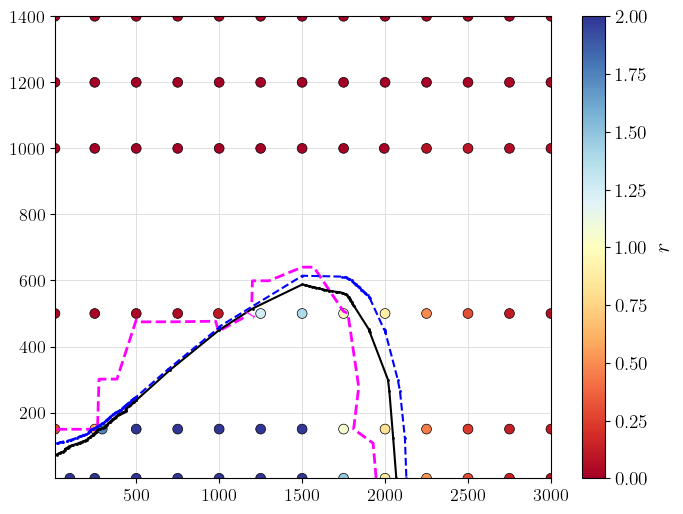

In [13]:
# signal_strength_obs
fig, ax = plt.subplots(figsize=(8,6))
# configure_axes(ax)

scatter = ax.scatter(
    max_sigma_exp_per_saf["mMed (GeV)"],
    max_sigma_exp_per_saf["mchi (GeV)"],
    c=max_sigma_exp_per_saf["Signal Strength Obs"],
    cmap=cm,
    s=50,
    edgecolor="black",
    linewidth=0.5,
    marker='o',
    vmin=0,
    vmax=2
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("$r$", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# Contour for r ~ 1
x = max_sigma_exp_per_saf["mMed (GeV)"]
y = max_sigma_exp_per_saf["mchi (GeV)"]
z = max_sigma_exp_per_saf["Signal Strength Obs"]

xi, yi = np.meshgrid(
    np.linspace(x.min(), x.max(), 200),
    np.linspace(y.min(), y.max(), 200)
)
zi = griddata((x, y), z, (xi, yi), method='linear')

#contour = ax.contour(xi, yi, zi, levels=[1], colors="magenta", linestyles="--", linewidths=1.5)
contour = ax.tricontour(x, y, z, levels=[1], colors="magenta", linestyles="--", linewidths=2)
ax.clabel(contour, inline=True, fontsize=12) #fmt="r = 1",
ax.plot(DataDF_Obs_DMA.iloc[:, 0], DataDF_Obs_DMA.iloc[:, 1], label='Obs', color='k', marker='o', linestyle='-', linewidth=1.5, markersize=1)
ax.plot(DataDF_Exp_DMA.iloc[:, 0], DataDF_Exp_DMA.iloc[:, 1], label='Expected', color='b', marker='o', linestyle='--', linewidth=1.5, markersize=1)

ax.set_x_label(r'$m_{Z^{\prime}}$ [GeV]')
ax.set_y_label(r'$m_{\chi}$ [GeV]')
plt.grid(True, linestyle='--', alpha=0.6)
# plt.ylim(290, 1000)
# plt.xlim(300, 2500)
ax.legend(frameon=False, loc='best')
plt.tight_layout()
plt.show()


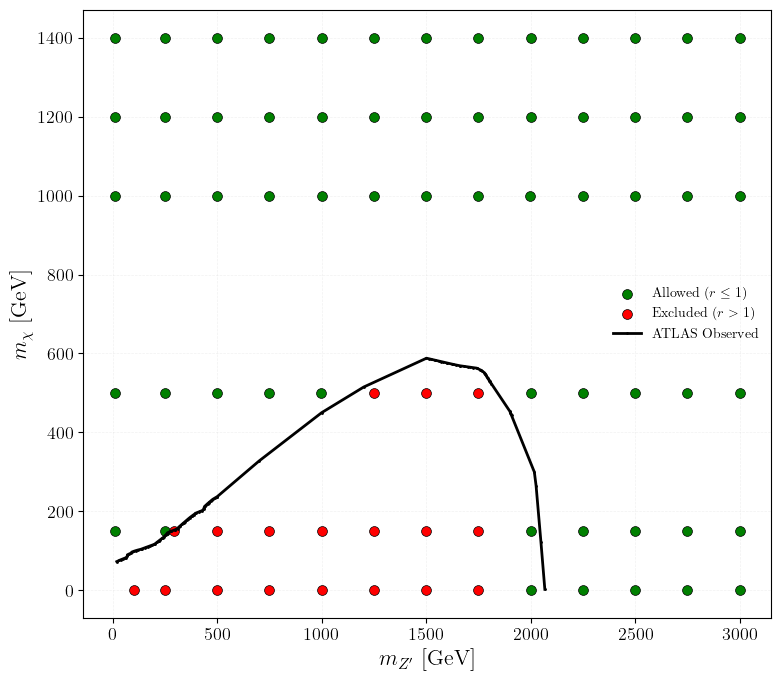

In [19]:
fig, ax = plt.subplots(figsize=(8, 7))
# configure_axes(ax)
# Add green points for r <= 1 (r Obs <= 1)
green_points = max_sigma_exp_per_saf[max_sigma_exp_per_saf["Signal Strength Obs"] <= 1]
ax.scatter(
    green_points["mMed (GeV)"],
    green_points["mchi (GeV)"],
    c="green",
    label=r"Allowed ($r \leq 1$)",
    s=50,
    edgecolor="black",
    linewidth=0.5
)

# Add red points for r >  1 (r Obs > 1)
red_points = max_sigma_exp_per_saf[max_sigma_exp_per_saf["Signal Strength Obs"] > 1]
ax.scatter(
    red_points["mMed (GeV)"],
    red_points["mchi (GeV)"],
    c="red",
    label=r"Excluded ($r > 1$)",
    s=50,
    edgecolor="black",
    linewidth=0.5
)

# Contour for mu ~ 1
x = max_sigma_exp_per_saf["mMed (GeV)"]
y = max_sigma_exp_per_saf["mchi (GeV)"]
z = max_sigma_exp_per_saf["Signal Strength Obs"]
xi, yi = np.meshgrid(
    np.linspace(x.min(), x.max(), 200),
    np.linspace(y.min(), y.max(), 200)
)
zi = griddata((x, y), z, (xi, yi), method='linear')
#contour = ax.contour(xi, yi, zi, levels=[1], colors="magenta", linestyles="--", linewidths=2)
#ax.clabel(contour, fmt="r = 1", inline=True, fontsize=12)
#ax.plot(hep_data_ttbnffObs['mMed [GeV]'], hep_data_ttbnffObs['mchi [GeV]'], color="black", label='ATLAS Observation', linewidth=1)
ax.plot(DataDF_Obs_DMA.iloc[:, 0], DataDF_Obs_DMA.iloc[:, 1], label=r'ATLAS Observed', color='k', marker='o', linestyle='-', linewidth=2, markersize=1)
# ax.plot(DataDF_Exp_DMA.iloc[:, 0], DataDF_Exp_DMA.iloc[:, 1], label=r'ATLAS Expected', color='b', marker='o', linestyle='--', linewidth=1.5, markersize=1)
ax.set_xlabel(r'$m_{Z^{\prime}}$ [GeV]')
ax.set_ylabel(r'$m_{\chi}$ [GeV]')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.6)
# plt.ylim(10, 900)
# plt.xlim(10, 2500)
ax.legend(framealpha=0.0, loc='best')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('./plot-validation.png')

plt.show()
